# MVP v0.2.5.14f: Score Timestep Sweep (t=1–50)

**Date:** 2026-03-26  
**Builds on:** v0.2.5.14 (action_scale=0.01, rho=0.71), v0.2.5.4 (isolated gradient timestep sweep)

## Goal

Sweep `score_timestep` in **full trajectory generation** with OPE evaluation.  
v0.2.5.4 tested timesteps in isolation (gradient quality only). This experiment tests
whether the t=5–10 sweet spot holds when guidance is applied end-to-end across
6 target policies, or whether higher t (weaker but more stable gradients) works
just as well in the stitching loop.

## Setup
- **Diffuser:** v0.2.5.2 EMA (200 demos + 50 rollouts, chunk_size=4, 256 steps)
- **Guidance:** positive-only, `action_scale=0.01`, `normalize_grad=True`
- **Sweep:** `score_timestep` in [1, 2, 5, 10, 20, 50]
- **Generation:** 50 synthetic trajectories, T_GEN=60
- **6 target policies** (oracle SR: 8%–90%)

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config (must match v0.2.5.2 training)
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0

# Guidance config — fixed action_scale from v0.2.5.14
ACTION_SCALE = 0.01
SIGMOID_SHARPNESS = 150.0

# Sweep config: score_timestep values (same as v0.2.5.4 gradient sweep)
SCORE_TIMESTEPS = [1, 2, 5, 10, 20, 50]

# Target policies (same as v0.2.5.14)
TARGET_POLICIES = [
    {"name": "10demos_epoch10", "dir": "lift_diffusion_10demos/20260311115828", "ckpt": "models/model_epoch_10.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint", "dir": "test/20260309132349", "ckpt": "last.pth"},
    {"name": "10demos_epoch30", "dir": "lift_diffusion_10demos/20260311115828", "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30", "dir": "lift_diffusion_50demos/20260311134204", "ckpt": "models/model_epoch_30.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"Sweep: score_timestep in {SCORE_TIMESTEPS}")
print(f"Fixed: action_scale={ACTION_SCALE}")
print(f"{len(TARGET_POLICIES)} policies x {len(SCORE_TIMESTEPS)} timesteps = {len(TARGET_POLICIES)*len(SCORE_TIMESTEPS)} guided runs")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
Sweep: score_timestep in [1, 2, 5, 10, 20, 50]
Fixed: action_scale=0.01
6 policies x 6 timesteps = 36 guided runs


In [2]:
# ── Reward + OPE functions ──
def hard_reward(cube_z):
    return (cube_z > LIFT_THRESHOLD).astype(np.float32)

def sigmoid_reward(cube_z, center=LIFT_THRESHOLD, sharpness=SIGMOID_SHARPNESS):
    return (1.0 / (1.0 + np.exp(-sharpness * (cube_z - center)))).astype(np.float32)

def compute_ope_hard(states, gamma=1.0):
    B, T, _ = states.shape
    cube_z = states[:, :, CUBE_Z_INDEX]
    rewards = hard_reward(cube_z)
    gammas = gamma ** np.arange(T)
    return (rewards * gammas[None, :]).sum(axis=1)

def compute_ope_sigmoid(states, gamma=1.0):
    B, T, _ = states.shape
    cube_z = states[:, :, CUBE_Z_INDEX]
    rewards = sigmoid_reward(cube_z)
    gammas = gamma ** np.arange(T)
    return (rewards * gammas[None, :]).sum(axis=1)

def compute_sr_hard(states):
    B = states.shape[0]
    cube_z = states[:, :, CUBE_Z_INDEX]
    return np.mean([np.any(cube_z[j] > LIFT_THRESHOLD) for j in range(B)])

print("Reward/OPE functions defined.")

Reward/OPE functions defined.


In [3]:
# ── Load oracle ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR values:")
for name, sr in oracle_sr_map.items():
    print(f"  {name:<22} {sr*100:.0f}%")

Oracle SR values:
  10demos_epoch10        8%
  100demos_epoch20       42%
  test_checkpoint        54%
  10demos_epoch30        62%
  50demos_epoch30        82%
  200demos_epoch40       90%


In [4]:
# ── Load data + normalization + diffuser ──
all_states_list, all_actions_list = [], []
target_data = []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
print(f"Loaded {len(target_data)} target rollouts")

with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
print(f"Loaded 200 expert demos")

all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")

# Load diffuser
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

Loaded 50 target rollouts


Loaded 200 expert demos


Initial states: torch.Size([50, 19])
[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


In [5]:
# ── Trajectory generator (positive-only guidance) ──

def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None,
    action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]

                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)

                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide

                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, 1:1+n_store]
        total += n_store

        if total < t_gen:
            last_state_norm = x[:, -1, :state_dim]
            conditions = {0: last_state_norm}

    return all_traj.cpu().numpy()

print("Generator ready.")

Generator ready.


In [6]:
# ── Pre-load all target policy algos (load each checkpoint once) ──
# We build scorers per-timestep in the sweep loop, but the algo is reusable.
target_algos = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    run_dir = CKPT_BASE / pol["dir"]
    print(f"Loading {name}...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(pol["ckpt"]))
    target_algos[name] = build_algo_from_checkpoint(ckpt, device=str(device))
    print(f"{time.time()-t0:.0f}s")
print(f"\nAll {len(target_algos)} policy algos loaded.")

Loading 10demos_epoch10... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'object', 'robot0_eef_quat', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[10:05:39] INFO     build_algo_from_checkpoint took 0.40 seconds to execute                           ]8;id=941540;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=589485;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

1s
Loading 100demos_epoch20... 

...

1s
Loading 200demos_epoch40... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_gripper_qpos', 'object', 'robot0_eef_quat', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


           INFO     build_algo_from_checkpoint took 0.36 seconds to execute                           ]8;id=204753;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=958181;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

1s

All 6 policy algos loaded.


In [7]:
# ── Generate unguided baseline (once) ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)

t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model,
    initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_time = time.time() - t0

unguided_states = unguided_trajs[:, :, :STATE_DIM]
unguided_sr_hard = compute_sr_hard(unguided_states)
unguided_returns_hard = compute_ope_hard(unguided_states, GAMMA)
unguided_returns_sigmoid = compute_ope_sigmoid(unguided_states, GAMMA)

print(f"Unguided: hard SR={unguided_sr_hard*100:.0f}%, "
      f"hard OPE={unguided_returns_hard.mean():.3f}, "
      f"sigmoid OPE={unguided_returns_sigmoid.mean():.3f}, "
      f"{unguided_time:.0f}s")

cube_z_max_per_traj = unguided_states[:, :, CUBE_Z_INDEX].max(axis=1)
print(f"Unguided cube_z max: mean={cube_z_max_per_traj.mean():.4f}, "
      f"std={cube_z_max_per_traj.std():.4f}, "
      f"range=[{cube_z_max_per_traj.min():.4f}, {cube_z_max_per_traj.max():.4f}]")

Generating unguided trajectories...


Unguided: hard SR=60%, hard OPE=5.020, sigmoid OPE=7.992, 31s
Unguided cube_z max: mean=0.8418, std=0.0101, range=[0.8225, 0.8551]


In [8]:
# ── Sweep: score_timestep x target_policy ──
sweep_results = {}  # key: (timestep, policy_name)
timestep_sigmas = {}  # map timestep -> sigma
t0_all = time.time()
total_runs = len(SCORE_TIMESTEPS) * len(TARGET_POLICIES)
run_count = 0

for st in SCORE_TIMESTEPS:
    print(f"\n{'='*80}")
    print(f"SCORE_TIMESTEP = {st}")
    print(f"{'='*80}")

    # Build scorers for this timestep (reuse pre-loaded algos)
    scorers = {}
    for name, algo in target_algos.items():
        scorers[name] = RobomimicDiffusionScorer(
            algo, device=str(device), score_timestep=st, obs_keys=OBS_KEYS
        )

    # Record sigma for this timestep (same for all policies)
    sigma = scorers[TARGET_POLICIES[0]["name"]].sigma
    timestep_sigmas[st] = sigma
    print(f"  sigma = {sigma:.4f} (1/sigma = {1/sigma:.1f}x)")

    for pol in TARGET_POLICIES:
        name = pol["name"]
        run_count += 1
        oracle_sr = oracle_sr_map[name]

        print(f"  [{run_count}/{total_runs}] {name} (oracle={oracle_sr*100:.0f}%)...", end=" ", flush=True)
        np.random.seed(42)
        torch.manual_seed(42)
        t0 = time.time()

        guided_trajs = generate_trajectories(
            diffusion_model=ema.ema_model, initial_states=initial_states_t,
            normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
            state_dim=STATE_DIM, action_dim=ACTION_DIM,
            chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
            target_scorer=scorers[name],
            action_scale=ACTION_SCALE, normalize_grad=True,
        )
        gen_time = time.time() - t0

        guided_states = guided_trajs[:, :, :STATE_DIM]
        sr = compute_sr_hard(guided_states)
        ope_hard_returns = compute_ope_hard(guided_states, GAMMA)
        ope_sigm_returns = compute_ope_sigmoid(guided_states, GAMMA)
        ope_hard = float(ope_hard_returns.mean())
        ope_sigm = float(ope_sigm_returns.mean())

        sweep_results[(st, name)] = {
            "oracle_sr": oracle_sr,
            "guided_sr": sr,
            "ope_hard": ope_hard,
            "ope_sigmoid": ope_sigm,
            "ope_hard_std": float(ope_hard_returns.std()),
            "ope_sigm_std": float(ope_sigm_returns.std()),
        }
        print(f"{gen_time:.0f}s — SR={sr*100:.0f}%, hard={ope_hard:.3f}, sigm={ope_sigm:.3f}")

total_time = time.time() - t0_all
print(f"\nTotal sweep: {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"\nTimestep -> sigma mapping:")
for st, sigma in timestep_sigmas.items():
    print(f"  t={st:>2}: sigma={sigma:.4f}")


SCORE_TIMESTEP = 1
  sigma = 0.0418 (1/sigma = 23.9x)
  [1/36] 10demos_epoch10 (oracle=8%)... 

69s — SR=50%, hard=2.280, sigm=5.811
  [2/36] 100demos_epoch20 (oracle=42%)... 

69s — SR=60%, hard=4.140, sigm=7.308
  [3/36] test_checkpoint (oracle=54%)... 

69s — SR=44%, hard=2.840, sigm=6.218
  [4/36] 10demos_epoch30 (oracle=62%)... 

69s — SR=60%, hard=3.940, sigm=6.928
  [5/36] 50demos_epoch30 (oracle=82%)... 

...

69s — SR=68%, hard=3.940, sigm=7.302
  [33/36] test_checkpoint (oracle=54%)... 

69s — SR=60%, hard=4.220, sigm=7.547
  [34/36] 10demos_epoch30 (oracle=62%)... 

69s — SR=70%, hard=5.020, sigm=7.803
  [35/36] 50demos_epoch30 (oracle=82%)... 

69s — SR=72%, hard=4.920, sigm=7.959
  [36/36] 200demos_epoch40 (oracle=90%)... 

69s — SR=68%, hard=4.380, sigm=7.469

Total sweep: 2497s (41.6 min)

Timestep -> sigma mapping:
  t= 1: sigma=0.0418
  t= 2: sigma=0.0579
  t= 5: sigma=0.1050
  t=10: sigma=0.1824
  t=20: sigma=0.3330
  t=50: sigma=0.7223


In [9]:
# ── Compute metrics per timestep ──
policy_names = [p["name"] for p in TARGET_POLICIES]
oracle_srs = np.array([oracle_sr_map[n] for n in policy_names])

def regret_at_k(oracle_vals, ope_vals, k):
    true_topk = np.argsort(oracle_vals)[-k:]
    est_topk = np.argsort(ope_vals)[-k:]
    return float(oracle_vals[true_topk].mean() - oracle_vals[est_topk].mean())

ts_metrics = {}
for st in SCORE_TIMESTEPS:
    opes_hard = np.array([sweep_results[(st, n)]["ope_hard"] for n in policy_names])
    opes_sigm = np.array([sweep_results[(st, n)]["ope_sigmoid"] for n in policy_names])
    guided_srs = np.array([sweep_results[(st, n)]["guided_sr"] for n in policy_names])

    opes_hard_norm = opes_hard / T_GEN
    opes_sigm_norm = opes_sigm / T_GEN

    rho_h, p_h = stats.spearmanr(oracle_srs, opes_hard)
    rho_s, p_s = stats.spearmanr(oracle_srs, opes_sigm)

    eps = 1e-6
    rmse_h = np.sqrt(np.mean((oracle_srs - opes_hard_norm) ** 2))
    rmse_s = np.sqrt(np.mean((oracle_srs - opes_sigm_norm) ** 2))
    log_rmse_h = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(opes_hard_norm + eps)) ** 2))
    log_rmse_s = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(opes_sigm_norm + eps)) ** 2))

    ts_metrics[st] = {
        "sigma": timestep_sigmas[st],
        "rho_hard": rho_h, "p_hard": p_h,
        "rho_sigm": rho_s, "p_sigm": p_s,
        "rmse_hard": rmse_h, "rmse_sigm": rmse_s,
        "log_rmse_hard": log_rmse_h, "log_rmse_sigm": log_rmse_s,
        "regret1_hard": regret_at_k(oracle_srs, opes_hard, 1),
        "regret3_hard": regret_at_k(oracle_srs, opes_hard, 3),
        "regret1_sigm": regret_at_k(oracle_srs, opes_sigm, 1),
        "regret3_sigm": regret_at_k(oracle_srs, opes_sigm, 3),
        "sr_range": (guided_srs.min(), guided_srs.max()),
        "ope_hard_range": (opes_hard.min(), opes_hard.max()),
    }

print("Metrics computed for all timesteps.")

Metrics computed for all timesteps.


In [10]:
# ── Summary table ──
print("=" * 120)
print("v0.2.5.14f: SCORE TIMESTEP SWEEP")
print(f"Fixed: action_scale={ACTION_SCALE}, pos-only, normalize_grad=True")
print("=" * 120)

# Per-timestep per-policy table
for st in SCORE_TIMESTEPS:
    m = ts_metrics[st]
    print(f"\n--- t={st} (sigma={m['sigma']:.4f}) | rho_hard={m['rho_hard']:+.3f} rho_sigm={m['rho_sigm']:+.3f} ---")
    for name in policy_names:
        r = sweep_results[(st, name)]
        print(f"  {name:<22} oracle={r['oracle_sr']*100:>5.0f}%  SR={r['guided_sr']*100:>5.0f}%  "
              f"hard={r['ope_hard']:>6.3f}  sigm={r['ope_sigmoid']:>6.3f}")

# Aggregate comparison
print(f"\n{'='*120}")
print(f"AGGREGATE METRICS BY TIMESTEP")
print(f"{'='*120}")
print(f"\n{'t':<4} {'sigma':>7} {'rho_H':>7} {'rho_S':>7} {'RMSE_H':>8} {'RMSE_S':>8} "
      f"{'logRMSE_H':>10} {'logRMSE_S':>10} {'R@1_H':>7} {'R@3_H':>7} {'R@1_S':>7} {'R@3_S':>7}")
print("-" * 110)
for st in SCORE_TIMESTEPS:
    m = ts_metrics[st]
    print(f"{st:<4} {m['sigma']:>7.4f} {m['rho_hard']:>+7.3f} {m['rho_sigm']:>+7.3f} "
          f"{m['rmse_hard']:>8.4f} {m['rmse_sigm']:>8.4f} "
          f"{m['log_rmse_hard']:>10.4f} {m['log_rmse_sigm']:>10.4f} "
          f"{m['regret1_hard']:>7.3f} {m['regret3_hard']:>7.3f} "
          f"{m['regret1_sigm']:>7.3f} {m['regret3_sigm']:>7.3f}")

# Best timestep
best_ts = max(SCORE_TIMESTEPS, key=lambda s: ts_metrics[s]["rho_hard"])
best_m = ts_metrics[best_ts]
print(f"\nBest timestep (by rho_hard): t={best_ts} (sigma={best_m['sigma']:.4f}) -> rho={best_m['rho_hard']:+.3f}")

best_ts_sigm = max(SCORE_TIMESTEPS, key=lambda s: ts_metrics[s]["rho_sigm"])
best_m_sigm = ts_metrics[best_ts_sigm]
print(f"Best timestep (by rho_sigm): t={best_ts_sigm} (sigma={best_m_sigm['sigma']:.4f}) -> rho={best_m_sigm['rho_sigm']:+.3f}")

v0.2.5.14f: SCORE TIMESTEP SWEEP
Fixed: action_scale=0.01, pos-only, normalize_grad=True

--- t=1 (sigma=0.0418) | rho_hard=+0.257 rho_sigm=+0.371 ---
  10demos_epoch10        oracle=    8%  SR=   50%  hard= 2.280  sigm= 5.811
  100demos_epoch20       oracle=   42%  SR=   60%  hard= 4.140  sigm= 7.308
  test_checkpoint        oracle=   54%  SR=   44%  hard= 2.840  sigm= 6.218
  10demos_epoch30        oracle=   62%  SR=   60%  hard= 3.940  sigm= 6.928
  50demos_epoch30        oracle=   82%  SR=   66%  hard= 4.020  sigm= 7.199
  200demos_epoch40       oracle=   90%  SR=   58%  hard= 3.840  sigm= 6.944

--- t=2 (sigma=0.0579) | rho_hard=+0.200 rho_sigm=+0.200 ---
  10demos_epoch10        oracle=    8%  SR=   58%  hard= 2.500  sigm= 6.033
  100demos_epoch20       oracle=   42%  SR=   64%  hard= 4.620  sigm= 7.547
  test_checkpoint        oracle=   54%  SR=   40%  hard= 2.660  sigm= 6.103
  10demos_epoch30        oracle=   62%  SR=   62%  hard= 4.180  sigm= 7.197
  50demos_epoch30        or

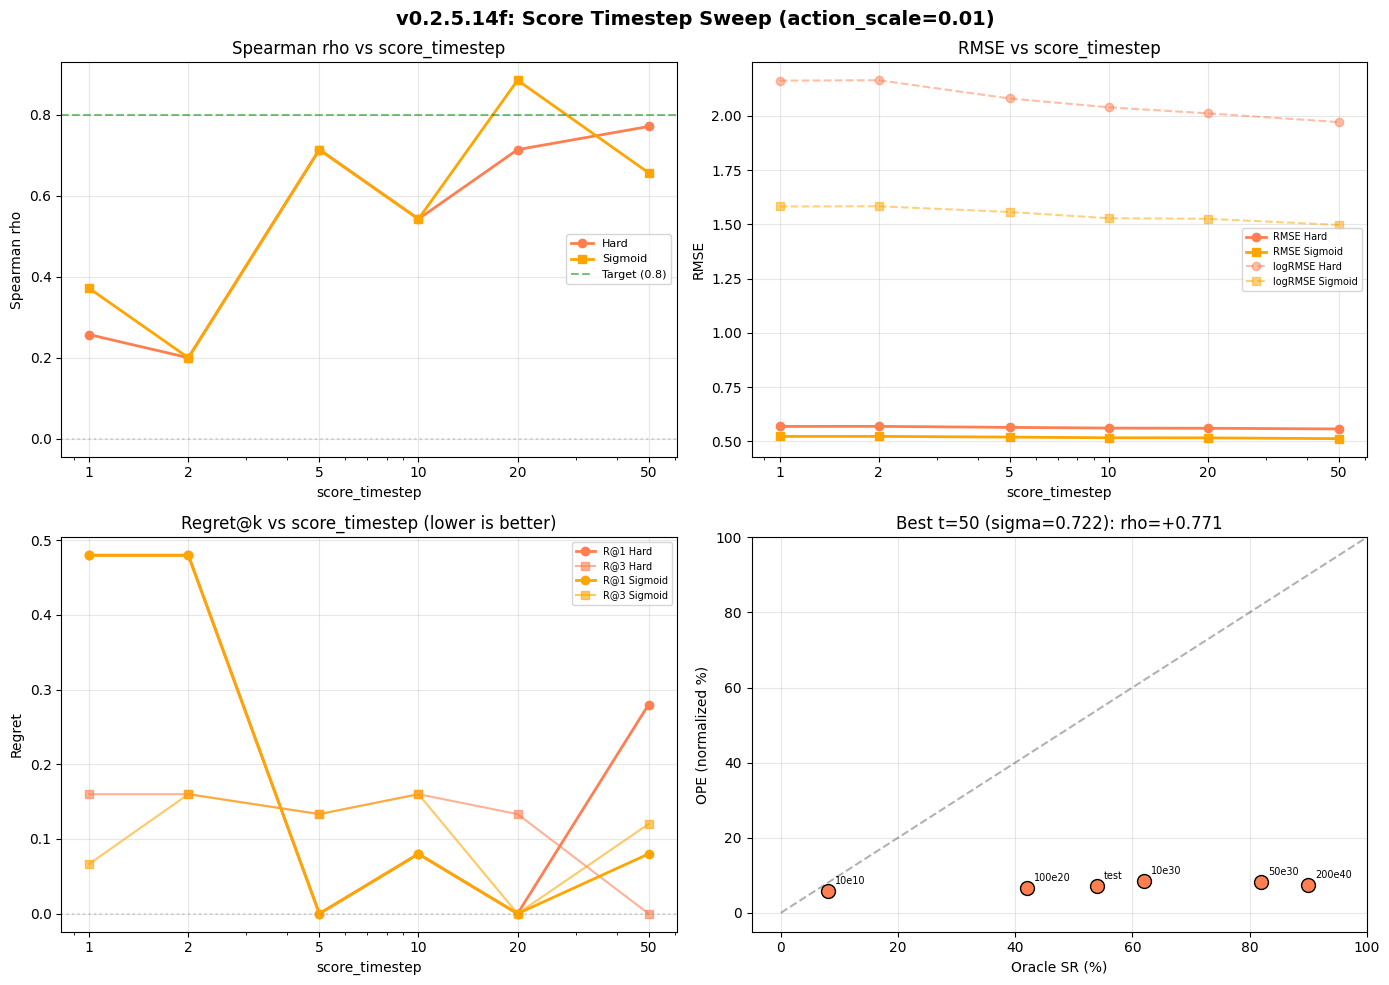

In [11]:
# ── Figure 1: Metrics vs score_timestep ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ts_list = SCORE_TIMESTEPS

# Panel 1: Spearman rho vs timestep
ax = axes[0, 0]
ax.plot(ts_list, [ts_metrics[t]["rho_hard"] for t in ts_list], 'o-', color="coral", label="Hard", lw=2)
ax.plot(ts_list, [ts_metrics[t]["rho_sigm"] for t in ts_list], 's-', color="orange", label="Sigmoid", lw=2)
ax.axhline(0.8, color="green", ls="--", alpha=0.5, label="Target (0.8)")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel("score_timestep")
ax.set_ylabel("Spearman rho")
ax.set_title("Spearman rho vs score_timestep")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")
ax.set_xticks(ts_list)
ax.set_xticklabels([str(t) for t in ts_list])

# Panel 2: RMSE vs timestep
ax = axes[0, 1]
ax.plot(ts_list, [ts_metrics[t]["rmse_hard"] for t in ts_list], 'o-', color="coral", label="RMSE Hard", lw=2)
ax.plot(ts_list, [ts_metrics[t]["rmse_sigm"] for t in ts_list], 's-', color="orange", label="RMSE Sigmoid", lw=2)
ax.plot(ts_list, [ts_metrics[t]["log_rmse_hard"] for t in ts_list], 'o--', color="coral", alpha=0.5, label="logRMSE Hard")
ax.plot(ts_list, [ts_metrics[t]["log_rmse_sigm"] for t in ts_list], 's--', color="orange", alpha=0.5, label="logRMSE Sigmoid")
ax.set_xlabel("score_timestep")
ax.set_ylabel("RMSE")
ax.set_title("RMSE vs score_timestep")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")
ax.set_xticks(ts_list)
ax.set_xticklabels([str(t) for t in ts_list])

# Panel 3: Regret@1 and @3 vs timestep
ax = axes[1, 0]
ax.plot(ts_list, [ts_metrics[t]["regret1_hard"] for t in ts_list], 'o-', color="coral", label="R@1 Hard", lw=2)
ax.plot(ts_list, [ts_metrics[t]["regret3_hard"] for t in ts_list], 's-', color="coral", alpha=0.6, label="R@3 Hard")
ax.plot(ts_list, [ts_metrics[t]["regret1_sigm"] for t in ts_list], 'o-', color="orange", label="R@1 Sigmoid", lw=2)
ax.plot(ts_list, [ts_metrics[t]["regret3_sigm"] for t in ts_list], 's-', color="orange", alpha=0.6, label="R@3 Sigmoid")
ax.axhline(0, color="gray", ls=":", alpha=0.3)
ax.set_xlabel("score_timestep")
ax.set_ylabel("Regret")
ax.set_title("Regret@k vs score_timestep (lower is better)")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
ax.set_xscale("log")
ax.set_xticks(ts_list)
ax.set_xticklabels([str(t) for t in ts_list])

# Panel 4: OPE scatter at best timestep
ax = axes[1, 1]
best = best_ts
opes_best = np.array([sweep_results[(best, n)]["ope_hard"] / T_GEN for n in policy_names])
ax.scatter(oracle_srs * 100, opes_best * 100, s=100, c="coral", edgecolor="black", zorder=5)
for j, n in enumerate(policy_names):
    label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
    ax.annotate(label, (oracle_srs[j]*100, opes_best[j]*100),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3)
ax.set_xlabel("Oracle SR (%)")
ax.set_ylabel("OPE (normalized %)")
ax.set_title(f"Best t={best} (sigma={timestep_sigmas[best]:.3f}): rho={ts_metrics[best]['rho_hard']:+.3f}")
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 100)
ax.set_ylim(-5, 100)

fig.suptitle(f"v0.2.5.14f: Score Timestep Sweep (action_scale={ACTION_SCALE})", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

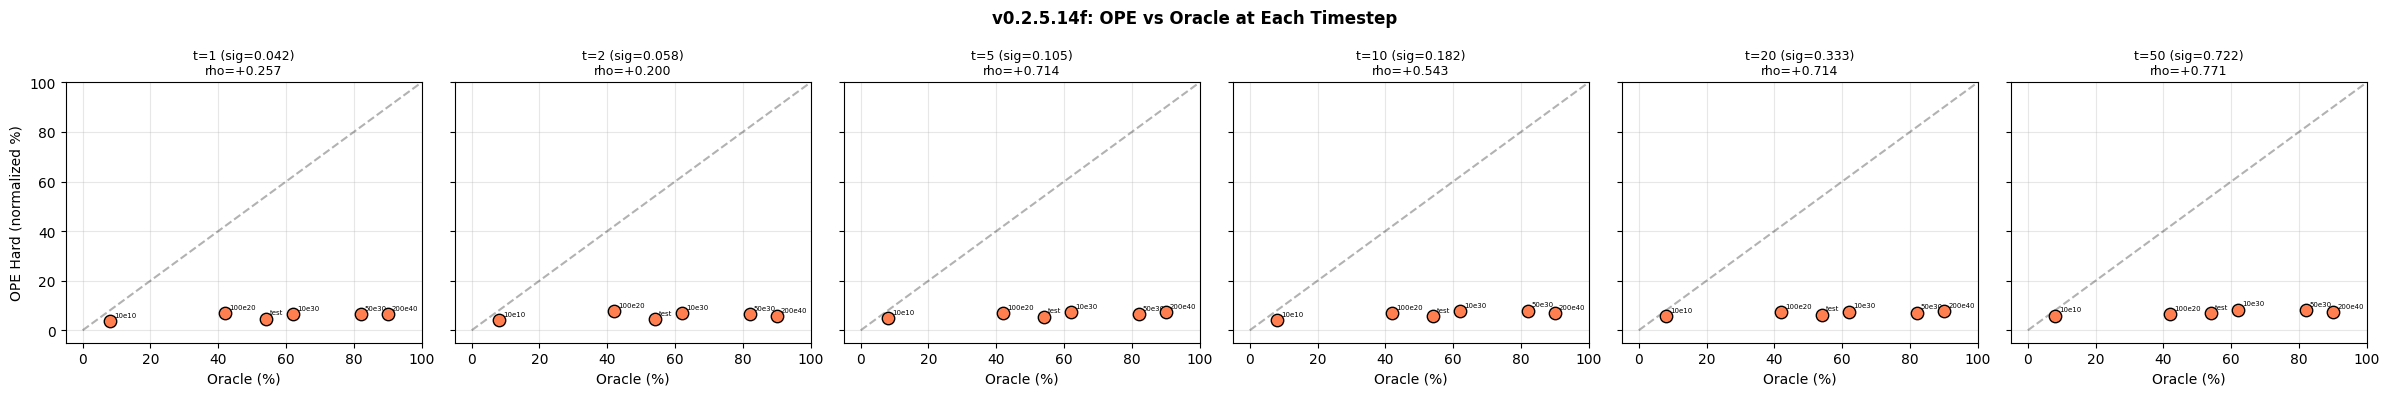

In [12]:
# ── Figure 2: OPE scatter at each timestep ──
fig, axes = plt.subplots(1, len(SCORE_TIMESTEPS), figsize=(4*len(SCORE_TIMESTEPS), 4), sharey=True)

for ax, st in zip(axes, SCORE_TIMESTEPS):
    opes = np.array([sweep_results[(st, n)]["ope_hard"] / T_GEN for n in policy_names])
    m = ts_metrics[st]
    ax.scatter(oracle_srs * 100, opes * 100, s=80, c="coral", edgecolor="black", zorder=5)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3)
    for j, n in enumerate(policy_names):
        label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
        ax.annotate(label, (oracle_srs[j]*100, opes[j]*100),
                    textcoords="offset points", xytext=(3, 3), fontsize=5)
    ax.set_xlabel("Oracle (%)")
    ax.set_title(f"t={st} (sig={timestep_sigmas[st]:.3f})\nrho={m['rho_hard']:+.3f}", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 100)
    ax.set_ylim(-5, 100)

axes[0].set_ylabel("OPE Hard (normalized %)")
fig.suptitle("v0.2.5.14f: OPE vs Oracle at Each Timestep", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

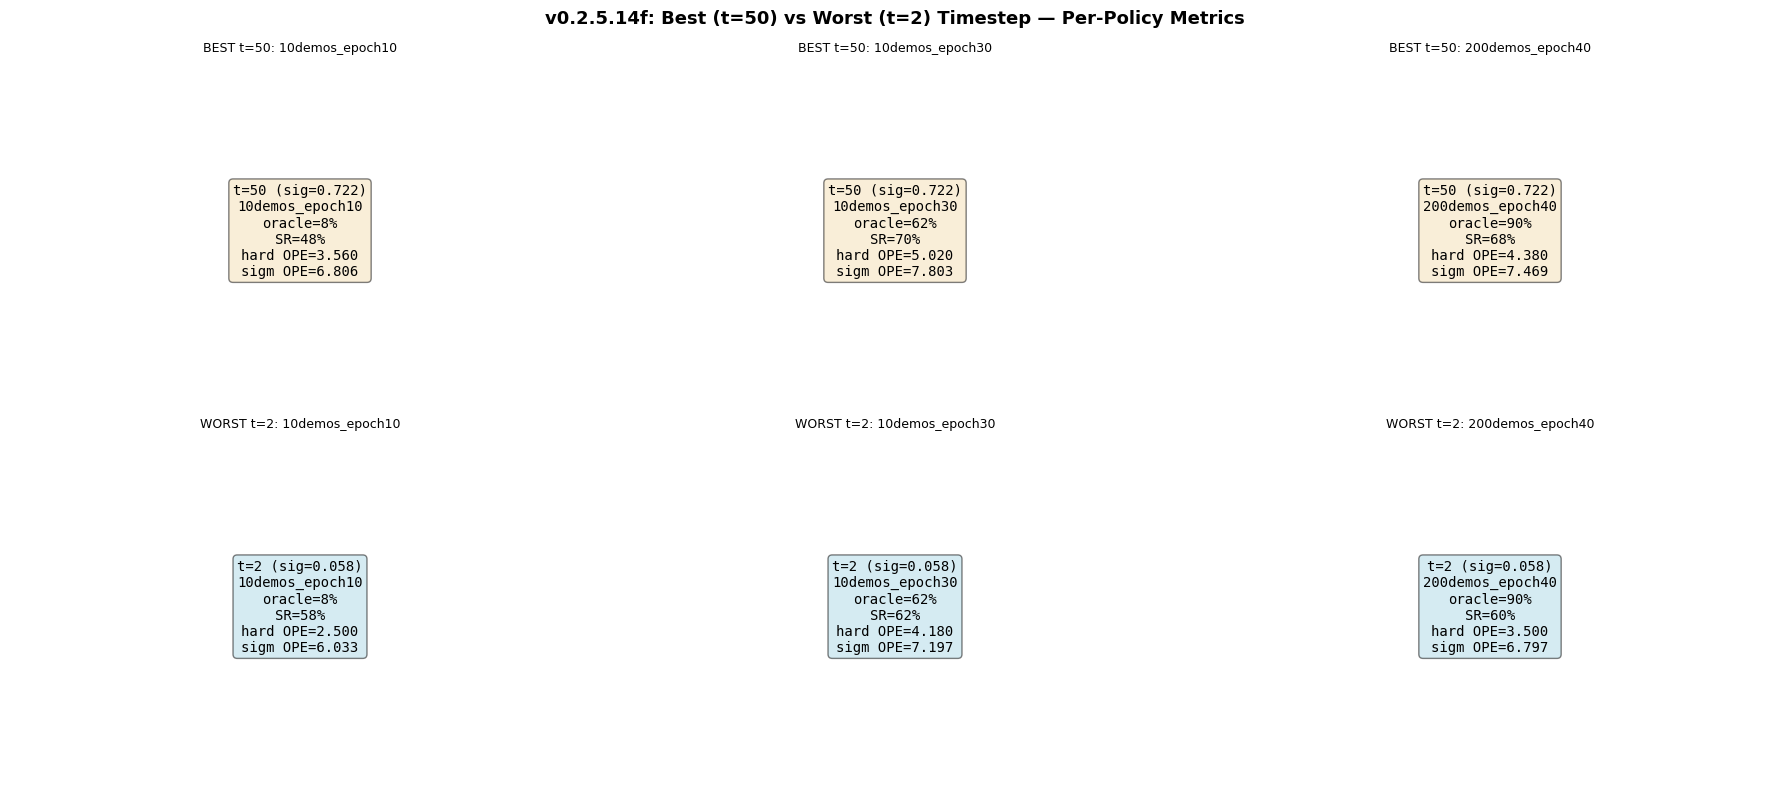

In [13]:
# ── Figure 3: Cube z trajectory grid (best vs worst timestep) ──
best_t = best_ts
worst_t = min(SCORE_TIMESTEPS, key=lambda s: ts_metrics[s]["rho_hard"])

# Pick the highest-oracle policy for visual comparison
best_pol = max(policy_names, key=lambda n: oracle_sr_map[n])

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for row, st in enumerate([best_t, worst_t]):
    for col, pol_name in enumerate([policy_names[0], policy_names[len(policy_names)//2], policy_names[-1]]):
        ax = axes[row, col]
        r = sweep_results[(st, pol_name)]

        # Re-generate just for visualization would be expensive — instead show
        # unguided as reference and annotate with metrics
        ax.text(0.5, 0.5,
                f"t={st} (sig={timestep_sigmas[st]:.3f})\n"
                f"{pol_name}\n"
                f"oracle={r['oracle_sr']*100:.0f}%\n"
                f"SR={r['guided_sr']*100:.0f}%\n"
                f"hard OPE={r['ope_hard']:.3f}\n"
                f"sigm OPE={r['ope_sigmoid']:.3f}",
                transform=ax.transAxes, ha="center", va="center", fontsize=10,
                fontfamily="monospace",
                bbox=dict(boxstyle="round", facecolor="wheat" if row == 0 else "lightblue", alpha=0.5))
        ax.set_title(f"{'BEST' if row == 0 else 'WORST'} t={st}: {pol_name}", fontsize=9)
        ax.axis("off")

fig.suptitle(f"v0.2.5.14f: Best (t={best_t}) vs Worst (t={worst_t}) Timestep — Per-Policy Metrics",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

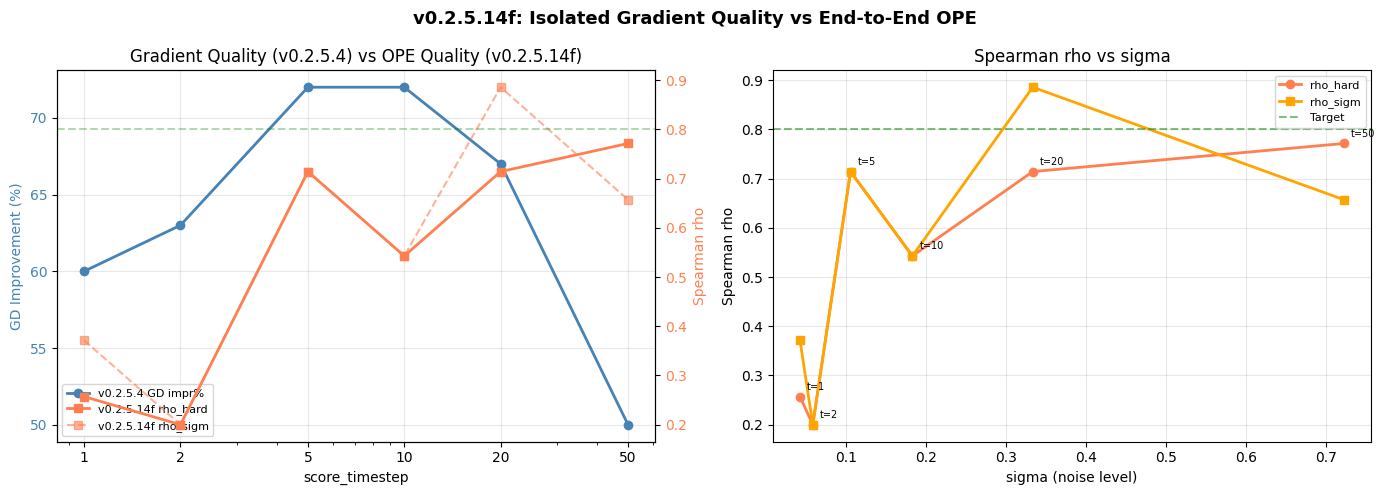

In [14]:
# ── Figure 4: v0.2.5.4 gradient sweep vs v0.2.5.14f OPE sweep comparison ──
# Reference data from v0.2.5.4 Part 1 (isolated gradient quality)
v054_gd_impr = {1: 60, 2: 63, 5: 72, 10: 72, 20: 67, 50: 50}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Overlay — gradient GD impr% vs OPE rho
ax1 = axes[0]
color1 = "steelblue"
color2 = "coral"

ax1.plot(ts_list, [v054_gd_impr[t] for t in ts_list], 'o-', color=color1, lw=2, label="v0.2.5.4 GD impr%")
ax1.set_xlabel("score_timestep")
ax1.set_ylabel("GD Improvement (%)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xscale("log")
ax1.set_xticks(ts_list)
ax1.set_xticklabels([str(t) for t in ts_list])
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ts_list, [ts_metrics[t]["rho_hard"] for t in ts_list], 's-', color=color2, lw=2, label="v0.2.5.14f rho_hard")
ax2.plot(ts_list, [ts_metrics[t]["rho_sigm"] for t in ts_list], 's--', color=color2, alpha=0.6, label="v0.2.5.14f rho_sigm")
ax2.set_ylabel("Spearman rho", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(0.8, color="green", ls="--", alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower left")
ax1.set_title("Gradient Quality (v0.2.5.4) vs OPE Quality (v0.2.5.14f)")

# Panel 2: sigma on x-axis instead of timestep
ax = axes[1]
sigmas = [timestep_sigmas[t] for t in ts_list]
ax.plot(sigmas, [ts_metrics[t]["rho_hard"] for t in ts_list], 'o-', color="coral", lw=2, label="rho_hard")
ax.plot(sigmas, [ts_metrics[t]["rho_sigm"] for t in ts_list], 's-', color="orange", lw=2, label="rho_sigm")
for i, t in enumerate(ts_list):
    ax.annotate(f"t={t}", (sigmas[i], ts_metrics[t]["rho_hard"]),
                textcoords="offset points", xytext=(5, 5), fontsize=7)
ax.axhline(0.8, color="green", ls="--", alpha=0.5, label="Target")
ax.set_xlabel("sigma (noise level)")
ax.set_ylabel("Spearman rho")
ax.set_title("Spearman rho vs sigma")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

fig.suptitle("v0.2.5.14f: Isolated Gradient Quality vs End-to-End OPE", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

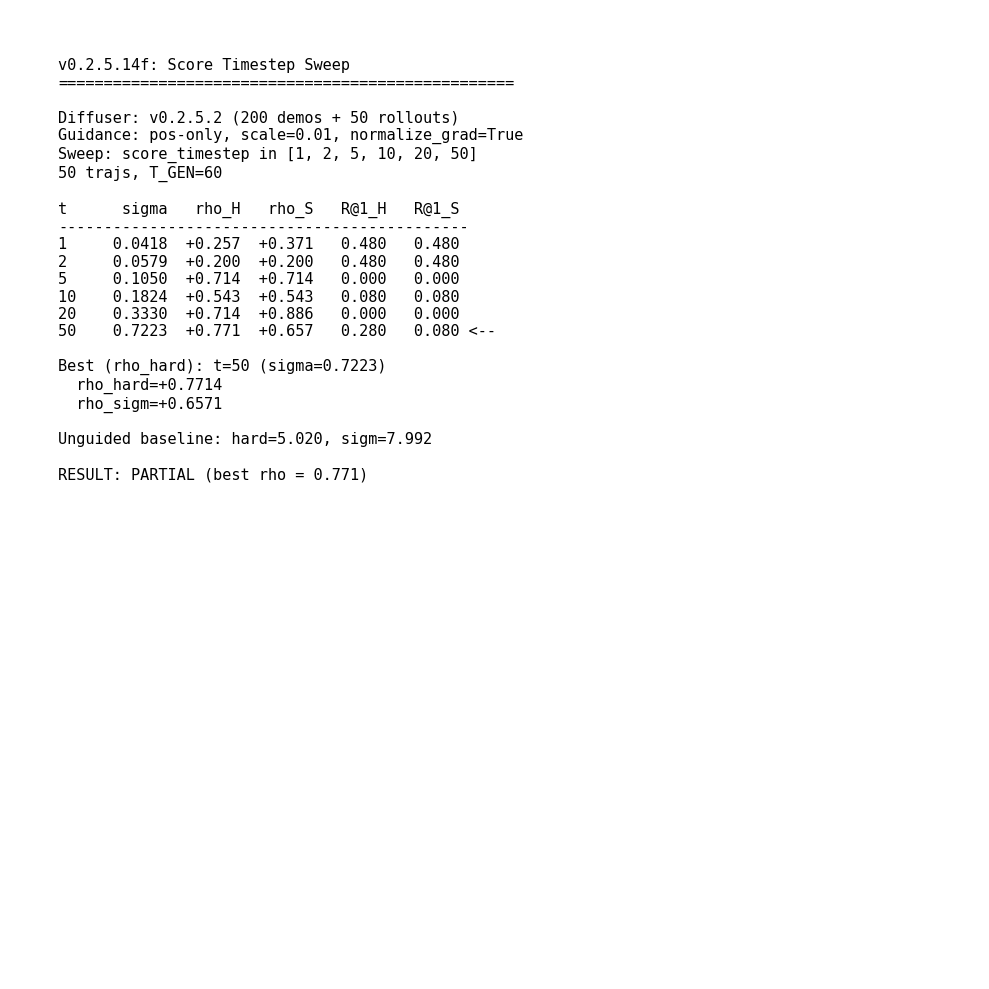

In [15]:
# ── Summary text ──
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.axis("off")

lines = [
    "v0.2.5.14f: Score Timestep Sweep",
    "=" * 50,
    "",
    f"Diffuser: v0.2.5.2 (200 demos + 50 rollouts)",
    f"Guidance: pos-only, scale={ACTION_SCALE}, normalize_grad=True",
    f"Sweep: score_timestep in {SCORE_TIMESTEPS}",
    f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}",
    "",
    f"{'t':<4} {'sigma':>7} {'rho_H':>7} {'rho_S':>7} {'R@1_H':>7} {'R@1_S':>7}",
    "-" * 45,
]

for st in SCORE_TIMESTEPS:
    m = ts_metrics[st]
    marker = " <--" if st == best_ts else ""
    lines.append(f"{st:<4} {m['sigma']:>7.4f} {m['rho_hard']:>+7.3f} {m['rho_sigm']:>+7.3f} "
                 f"{m['regret1_hard']:>7.3f} {m['regret1_sigm']:>7.3f}{marker}")

lines += [
    "",
    f"Best (rho_hard): t={best_ts} (sigma={ts_metrics[best_ts]['sigma']:.4f})",
    f"  rho_hard={ts_metrics[best_ts]['rho_hard']:+.4f}",
    f"  rho_sigm={ts_metrics[best_ts]['rho_sigm']:+.4f}",
    "",
    f"Unguided baseline: hard={float(unguided_returns_hard.mean()):.3f}, "
    f"sigm={float(unguided_returns_sigmoid.mean()):.3f}",
    "",
]

best_rho = max(ts_metrics[best_ts]["rho_hard"], ts_metrics[best_ts]["rho_sigm"])
if best_rho > 0.8:
    lines.append("RESULT: SUCCESS (best rho > 0.8)")
elif best_rho > 0.5:
    lines.append(f"RESULT: PARTIAL (best rho = {best_rho:.3f})")
else:
    lines.append(f"RESULT: FAIL (best rho = {best_rho:.3f})")

ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=11, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()